In [ ]:
# Write a python code to calculate the expected number of counts based on Poisson statistics that an X-ray telescope will observe from a given point source for a given exposure time. You can assume that the point source is at the detector's zenith for the entire duration of exposure time. The spectral profile of the source is given by `get_spectrum()`, the instrument response function R is composed of three contributions, the point spread function P, the energy redistribution function D, and the effective area A. The incident photon energy range is given as Emin to Emax and the measured energy range is E'min to E'max.

import numpy as np
from scipy.integrate import dblquad
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

# Placeholder for the source spectral profile: returns flux in photons/cm^2/s/keV
def get_spectrum(E):
    # Example: simple power-law spectrum with index -2
    return 1e-3 * (E ** -2)

# Placeholder for point spread function P(E, E')
def point_spread_function(E, E_prime):
    return 1.0  # Assuming unity for zenith source

# Placeholder for energy redistribution function D(E, E')
def energy_redistribution(E, E_prime):
    # Example: Gaussian centered on E with sigma = 0.1*E
    sigma = 0.1 * E
    return np.exp(-(E_prime - E)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

# Placeholder for effective area A(E): in cm^2
def effective_area(E):
    # Example: Effective area drops with energy
    return 1000 * np.exp(-E / 10)

# Combined response function R(E, E') = P * D * A
def response_function(E, E_prime):
    P = point_spread_function(E, E_prime)
    D = energy_redistribution(E, E_prime)
    A = effective_area(E)
    return P * D * A

# Integration bounds
E_min = 0.1   # keV
E_max = 10.0  # keV
E_prime_min = 0.1  # keV
E_prime_max = 10.0 # keV

# Exposure time in seconds
exposure_time = 1000  # seconds

# Expected number of counts
def expected_counts(get_spectrum=get_spectrum):
    integrand = lambda E_prime, E: get_spectrum(E) * response_function(E, E_prime)
    counts, err = dblquad(integrand, E_min, E_max, lambda E: E_prime_min, lambda E: E_prime_max)
    return counts * exposure_time  # photons over total exposure

# Compute result
counts = expected_counts()
print(f"Expected number of counts: {counts:.2f}")

Expected number of counts: 9085.61


In [75]:
# Reusing previous definitions: get_spectrum(), response_function(), exposure_time
# Energy bins
E_true = np.linspace(0.1, 10.0, 1001)
E_measured = np.linspace(0.1, 10.0, 1001)
dE_true = E_true[1] - E_true[0]
dE_measured = E_measured[1] - E_measured[0]

# Create 2D probability map (unnormalized)
prob_map = np.zeros((len(E_true), len(E_measured)))
for i, E in enumerate(E_true):
    for j, E_p in enumerate(E_measured):
        prob_map[i, j] = get_spectrum(E) * response_function(E, E_p)

# Normalize to get probabilities
prob_map *= dE_true * dE_measured
total_prob = np.sum(prob_map)
prob_map /= total_prob

# Expected number of events
expected_n = expected_counts()#int(total_prob * exposure_time)
n_events = np.random.poisson(expected_n)

# Flatten the 2D map and sample
flat_probs = prob_map.ravel()
indices = np.random.choice(len(flat_probs), size=n_events, p=flat_probs)

# Convert indices back to energy values
i_true, j_meas = np.unravel_index(indices, prob_map.shape)
sampled_E_measured = E_measured[j_meas]

# Generate event list: (arrival_time, measured_energy)
arrival_times = np.sort(np.random.uniform(0, exposure_time, n_events))
photon_events = {'TimeTags[s]': arrival_times, 'Energies': sampled_E_measured}

# Display sample
for i in range(10):
    print(f"Time: {photon_events['TimeTags[s]'][i]:.2f} s, Measured Energy: {photon_events['Energies'][i]:.2f} keV")

Time: 0.14 s, Measured Energy: 0.25 keV
Time: 0.19 s, Measured Energy: 5.52 keV
Time: 0.39 s, Measured Energy: 0.36 keV
Time: 0.39 s, Measured Energy: 0.16 keV
Time: 0.49 s, Measured Energy: 0.10 keV
Time: 0.63 s, Measured Energy: 0.52 keV
Time: 0.63 s, Measured Energy: 0.18 keV
Time: 0.79 s, Measured Energy: 0.17 keV
Time: 0.87 s, Measured Energy: 1.06 keV
Time: 0.91 s, Measured Energy: 1.15 keV


In [76]:
expected_n, expected_counts(), n_events

(9085.606318979573, 9085.606318979573, 9057)

In [104]:
def compute_log_likelihood(Energies, E_true, E_measured, get_spectrum=get_spectrum, 
                           response_function=response_function, expected_counts=expected_counts,
                           resolution_keV = 0.1):
    """
    Compute unbinned Poisson log-likelihood of measured photon energies.

    Parameters:
        photon_events (dict): Dictionary with keys 'Energies' containing measured photon energies.
        E_true (np.ndarray): True photon energy grid.
        E_measured (np.ndarray): Measured photon energy grid.
        get_spectrum (callable): Function returning photon flux for a given true energy.
        response_function (callable): Function R(E, E') = P * D * A.
        expected_counts (callable): Function returning expected number of total counts.

    Returns:
        float: Log-likelihood value.
    """
    # Step 1: Compute expected differential rate at each E'
    measured_rate = np.zeros_like(E_measured)
    for i, E_p in enumerate(E_measured):
        integrand = [get_spectrum(E) * response_function(E, E_p) for E in E_true]
        measured_rate[i] = np.trapz(integrand, E_true)

    # Apply Gaussian smoothing in energy bins
    bin_width_keV = np.mean(dE_measured)
    sigma_bins = resolution_keV / bin_width_keV
    smoothed_rate = measured_rate#gaussian_filter1d(measured_rate, sigma=sigma_bins)

    # Normalize to get PDF over E'
    pdf_Ep = smoothed_rate / np.trapz(smoothed_rate, E_measured)

    # Interpolation function for log(P(E'))
    pdf_interp = interp1d(E_measured, pdf_Ep, kind='linear', bounds_error=False, fill_value=1e-6)
    # plt.plot(pdf_interp(Energies))
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.show()

    log_pdf_func = lambda e: np.log(pdf_interp(e))

    # Step 2: Calculate log-likelihood
    measured_energies = Energies
    logL = np.sum(log_pdf_func(measured_energies)) - expected_counts(get_spectrum)

    return logL


In [111]:
def get_spectrum(E):
    # Example: simple power-law spectrum with index -2
    return 1e-3 * (E ** -2)

logL = compute_log_likelihood(np.random.choice(photon_events['Energies'], size=n_events, replace=True), 
                              E_true, E_measured, resolution_keV=0.1)
print(f"Unbinned log-likelihood: {logL:.2f}")

Unbinned log-likelihood: -4119.85


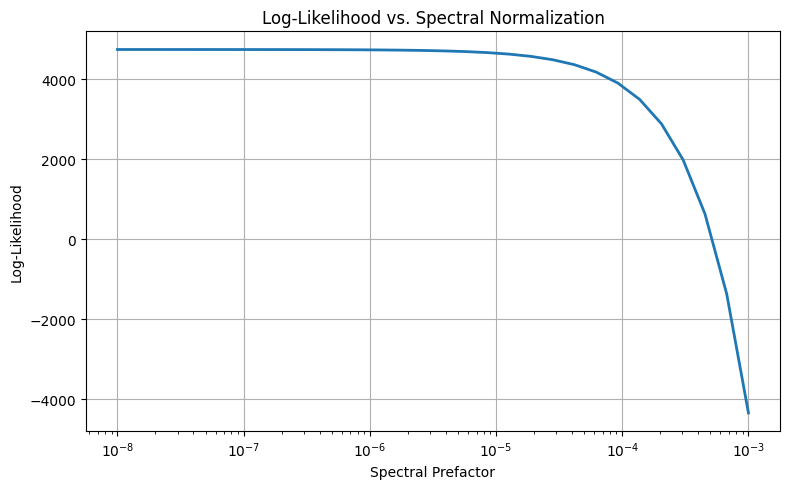

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define a wrapper for get_spectrum with variable prefactor
def make_get_spectrum(prefactor):
    def spectrum(E):
        return prefactor * (E ** -2)  # or your actual spectral shape
    return spectrum

# Sweep over a range of prefactor values
prefactor_values = np.logspace(-8, -3, 30)
logL_values = []

for norm in prefactor_values:
    custom_spectrum = make_get_spectrum(norm)
    logL = compute_log_likelihood(
        photon_events['Energies'],
        E_true, E_measured,
        custom_spectrum,
        response_function,
        expected_counts  # make sure this accepts the custom function!
    )
    logL_values.append(logL)

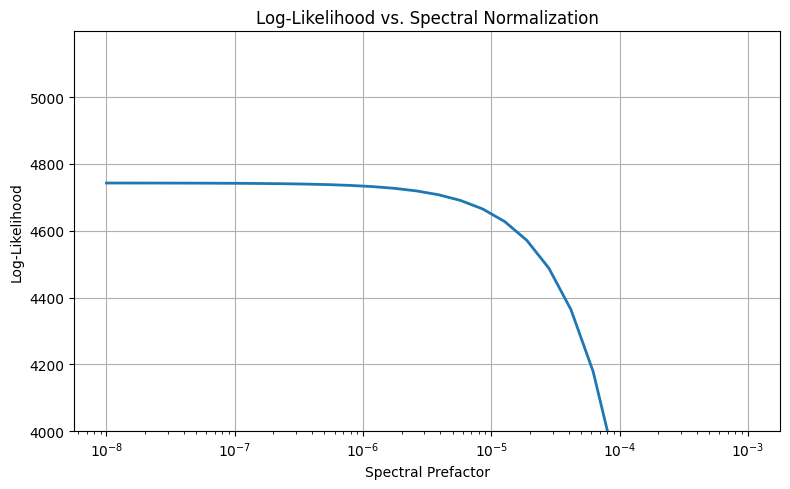

In [117]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(prefactor_values, logL_values, lw=2)
plt.xscale('log')
plt.xlabel("Spectral Prefactor")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. Spectral Normalization")
plt.ylim(bottom=4000)
plt.grid(True)
plt.tight_layout()
plt.show()

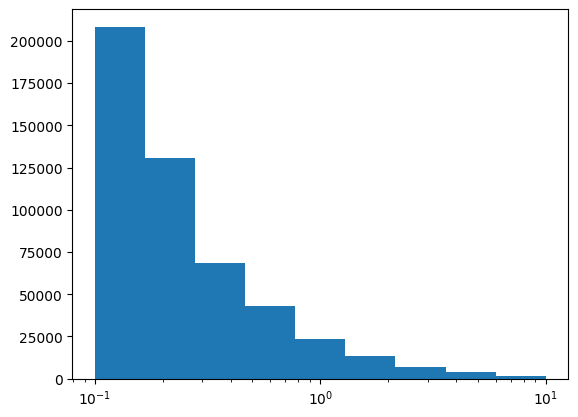

In [95]:
plt.hist(np.random.choice(photon_events['Energies'], size=500000, replace=True), 
         bins=np.geomspace(E_min, E_max, 10))
plt.xscale('log')

In [1]:
import numpy as np
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as const
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time
from scipy import integrate
import pandas as pd
from sparse import COO
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from lmfit.lineshapes import gaussian

from pathlib import Path
import itertools
import warnings

from cosipy.response import FullDetectorResponse, DetectorResponse, PointSourceResponse
from cosipy import UnBinnedData, BinnedData
from FullDetectorResponseNew import FullDetectorResponse
from DetectorResponseNew import DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data

from histpy import Histogram, Axes, Axis, HealpixAxis
import mhealpy as hp
from mhealpy import HealpixMap, HealpixBase
from scoords import Attitude, SpacecraftFrame

from threeML import Model, Powerlaw, Gaussian, Constant, Band
from tqdm import tqdm

from astromodels import PointSource
from threeML import PluginPrototype, Model, JointLikelihood, DataList

import copy
# from cosipy import COSILike

DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')
response_path = DATA_DIR / 'data/responses/DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5'
# response_path = DATA_DIR / 'data/responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5'

07:49:39 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=6177;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=48045;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=379522;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=698568;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=206164;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=355105;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=215300;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=908719;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

07:49:40 WARNING   No fermitools installed                                              ]8;id=732605;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=173797;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=186552;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=654776;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=688929;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=214302;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=148038;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=401409;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
pix = 0

with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    nside = f.nside
    # print(f._axes['NuLambda'].edges)
    dr = f[pix]

{'_file': <HDF5 file "DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (3 members)>, '_unit': Unit("cm2"), '_sparse': True, '_axes': <histpy.axes.Axes object at 0x287b5ed10>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 3, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 4503599627370496}


In [3]:
from threeML.plugin_prototype import PluginPrototype
from threeML.utils.statistics.likelihood_functions import poisson_log_likelihood_ideal_bkg

class COSILikeNew(PluginPrototype):

    def __init__(self, name, dr2, exposure_time, energy_samples, spectrum_unit, nuisance_param):
        super().__init__(name, nuisance_param)  # Or 'extended' if needed
        self._dr2 = dr2
        self._exposure_time = exposure_time.to('s')
        self._energy_samples = energy_samples
        self._spectrum_unit = spectrum_unit
        self._observed_events = energy_samples  # These are your Em samples
        self._n_observed = len(energy_samples)

    def set_model(self, likelihood_model):
        self._likelihood_model = likelihood_model

    def _compute_predicted_a(self):
        # Insert your final aj calculation loop here, using:
        # - self._likelihood_model.spectrum.main.shape(self._likelihood_model.parameters)
        # - self._dr2
        # - self._energy_samples
        # Return a numpy array of aj[j] values
        Eaxis = self._dr2.axes['Ei']
        spectrum = self._likelihood_model.source.spectrum.main.shape

        aj = []
        for Em in tqdm(self._energy_samples):
            rate_func = lambda E: spectrum(E.value) * self._spectrum_unit * self._dr2.get_interp_response({'Ei': E, 'Em': Em})
            idx = np.searchsorted(Eaxis.centers, Em, side='right')
            offsetter = Em / Eaxis.centers[idx-1] #Em / Eaxis.centers[idx]
            integral = sum(rate_func(Ei) * dE for Ei, dE in zip(Eaxis.centers * offsetter, Eaxis.widths * offsetter)) * self._exposure_time.to('s')       # Riemann sum approximation * exposure_time.to('s')       # Riemann sum approximation
            aj.append(integral)

        aj = Quantity(aj)
        return aj

    def _compute_predicted_c(self):
        Eaxis = self._dr2.axes['Ei']
        Epsedges = self._dr2.axes['Eps'].edges        # Can't densify further as get_interp_response only outputs (99,) shaped array
        Epscenters = (Epsedges[:-1] + Epsedges[1:]) / 2

        Eiedges = Eaxis.edges # densify_array(Eaxis.edges, k=1) * u.keV
        spectrum = self._likelihood_model.source.spectrum.main.shape

        integral = 0
        for Ei_low, Ei_high in zip(Eiedges[:-1], Eiedges[1:]):
            Ei = (Ei_low + Ei_high) / 2
            rate_func = spectrum(Ei.value) * self._spectrum_unit * (Ei_high - Ei_low) * self._exposure_time.to('s')

            Em = self._dr2.transform_Eps_to_Em(Epscenters, Ei)
            Em_high = self._dr2.transform_Eps_to_Em(Epsedges[1:], Ei)
            Em_low = self._dr2.transform_Eps_to_Em(Epsedges[:-1], Ei)

            integral += rate_func * np.sum(self._dr2.get_interp_response({'Ei': Ei}) * (Em_high - Em_low)) / Ei      # The denominator is the Jacobian term discussed in 20240924-ResponseRelativeCoordinates-cosipy-Israel.pdf page 7 when integrating over dEm instead of dEps (R is in Eps coordinates). dEps / dEm = 1/Ei
            
        c = integral
        return c

    def get_log_like(self):
        aj = self._compute_predicted_a()
        c = self._compute_predicted_c()
        log_like = -c + np.sum(np.log(aj + 1e-12))
        return log_like

    def inner_fit(self):
        return -2.0 * self.get_log_like()  # 3ML minimizes -2 logL

    def get_number_of_data_points(self):
        return self._n_observed

    def get_number_of_model_parameters(self):
        return self._likelihood_model.get_number_of_free_parameters()

In [3]:
def get_all_interp_weights(dr, target: dict):
    indices = []
    weights = []

    for label in dr.axes.labels:

        if label == 'Ei':
            key = label

        elif label == 'Eps':
            key = 'Em'

        elif label == 'Phi':
            key = label

        elif label == 'Theta':
            # label = 'ThetaZeta'
            axis_type = 'Axis'      # Theta, Zeta have axis_type = 'Axis'. PsiChi axis_type = 'HealpixAxis'

            # NuLambda_sc = np.array([0])         # Placeholder. FullDetectorResponse object depends on NuLambda. Detector Response object does not. 
            # I/O with radians not degrees
            Theta, Zeta = transform_PsiChi_to_ThetaZeta(target['Phi'].to(u.rad).value, \
                                                 target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)        # target['Ei', 'Em'] do not matter as we are throwing away the spectral component returned bu the function. 
            
            Theta = Theta * u.rad
            Zeta = Zeta * u.rad
            print(Theta, Zeta)

            # Theta axis
            idx, w = dr.axes['Theta'].interp_weights(Theta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            # Zeta axis
            idx, w = dr.axes['Zeta'].interp_weights(Zeta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            continue
    
        elif label == 'Zeta':
            continue

        else:
            raise ValueError(f'Label: {label} is not supported')
        
        axis = dr.axes[label]

        axis_scale = axis._scale
        axis_type = str(type(axis)).split('.')[-1].strip("'>")      # XXX: Could probably be simplified using `isinstance()`

        # Scale
        if axis_scale in ['linear', 'log']:   # To ensure nonlinear binning parametrizations are converted to a linear scale.

            # Axis Type
            if axis_type in ['Axis', 'HealpixAxis']:

                if key == 'Ei':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'Em':
                    centers = dr.transform_Eps_to_Em(axis.centers, target['Ei'])      # Transform coordinates to more physical units      # TODO: Generalize this
                    absdiff = np.abs(centers - target[key])                             # Calculate absolute difference to given target
                    idx = np.argpartition(absdiff, (1,2))[:2]                               # Find indices corresponding to two smallest absdiff
                    w = 1 - np.partition(absdiff, (1,2))[:2] / (centers[1] - centers[0])    # Calculate weights corresponding to two smallest absdiff

                elif key == 'Phi':
                    idx, w = axis.interp_weights(target[key])

            else:
                raise ValueError(f'Axis type: {axis_type} is not supported')

        else:
            raise ValueError(f'{axis_scale} binning / scale scheme is not supported')
        
        indices.append(idx)
        weights.append(w)
    
    return (indices, weights)

def get_interp_response(dr, target: dict):
    """
    Currently only supports nonlinear spectral responses (
    and for a particular parametrization)
    TODO: In the future, this will also support nonlinear / 
    piecewise-linear directional responses.
    """

    # target = dict(sorted(target.items()))       # Sort dictionary by key (XXX: assuming response matrix also sorts in the same way)
    indices, weights = get_all_interp_weights(dr, target)
    perm_indices = list(itertools.product(*indices))
    perm_weights = list(itertools.product(*weights))

    if len(target) == len(dr.axes):
        pass
    else:
        warnings.warn('len(target) != len(dr.axes)')
    
    interpolated_response_value = 0
    for idx, w in zip(perm_indices, perm_weights):
        interpolated_response_value += np.prod(w) * dr.contents[idx]
    
    return interpolated_response_value

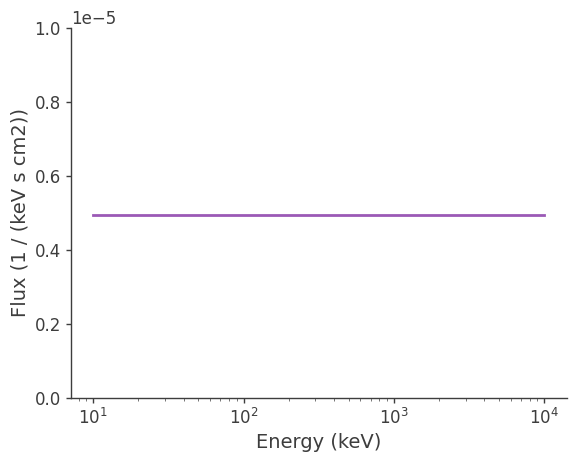

In [3]:
# Define Constant Flux Model (for Crab)
F = 4.95e-6 / u.cm / u.cm / u.keV / u.s

spectrum = Constant()
spectrum.k.value = F.value
spectrum.k.min_value = F.value / 1e4
spectrum.k.max_value = F.value * 1e4
spectrum.k.unit = F.unit
spectrum_unit = spectrum.k.unit

spectrum.k.free = True

# Generate some data for plotting
xdata = np.linspace(dr.axes['Ei'].edges[0], dr.axes['Ei'].edges[-1], 401)
ydata = spectrum(xdata.value) * spectrum_unit

# Plot the compound model
plt.plot(xdata, ydata)
plt.xlabel(f'Energy ({xdata.unit})')
plt.ylabel(f'Flux ({F.unit})')
plt.ylim([0, 1e-5])
plt.xscale('log')
plt.show()

07:50:32 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=221972;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=198291;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

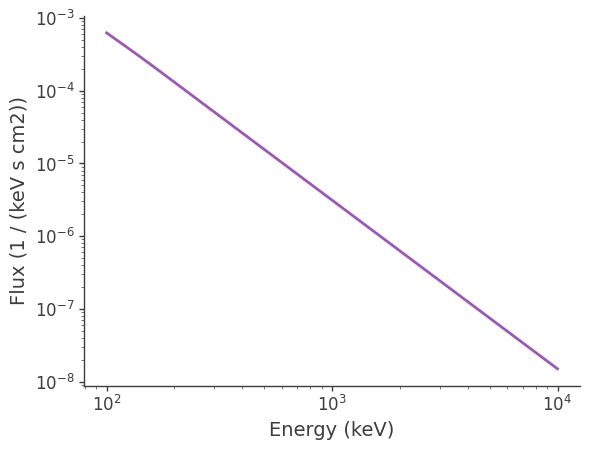

In [4]:
alpha_inj = -1.99
beta_inj = -2.32
E0_inj = 531. * (alpha_inj - beta_inj) * u.keV
xp_inj = E0_inj * (alpha_inj + 2) / (alpha_inj - beta_inj)
piv_inj = 100. * u.keV
K_inj = 7.56e-4 / u.cm / u.cm / u.s / u.keV

spectrum = Band()

spectrum.alpha.min_value = -2.14
spectrum.alpha.max_value = 3.0
spectrum.beta.min_value = -5.0
spectrum.beta.max_value = -2.15
spectrum.xp.min_value = 1.0

spectrum.alpha.value = alpha_inj
spectrum.beta.value = beta_inj
spectrum.xp.value = xp_inj.value
spectrum.K.value = K_inj.value
spectrum.piv.value = piv_inj.value

spectrum.xp.unit = xp_inj.unit
spectrum.K.unit = K_inj.unit
spectrum.piv.unit = piv_inj.unit

spectrum_unit = spectrum.K.unit

# Generate some data for plotting
xdata = np.geomspace(100, 10000, 201) * u.keV
ydata = spectrum(xdata.value) * spectrum_unit

# Plot the compound model
plt.plot(xdata, ydata)
plt.xlabel(f'Energy ({xdata.unit})')
plt.ylabel(f'Flux ({K_inj.unit})')
# plt.ylim([0, 1e-5])
plt.xscale('log')
plt.yscale('log')
plt.show()

In [5]:
point_source = UnBinnedData(DATA_DIR / '511/inputs.yaml')
# data = point_source.get_dict_from_fits(DATA_DIR / 'Crab/sources/Crab_Flat_Spectrum_3months_unbinned_data_filtered_with_SAAcut.fits')
data = point_source.get_dict_from_fits(DATA_DIR / 'Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')     # Data is already cut below 100 keV

idx = data['Energies'] < 10**3.25
data['Energies'] = data['Energies'][idx]

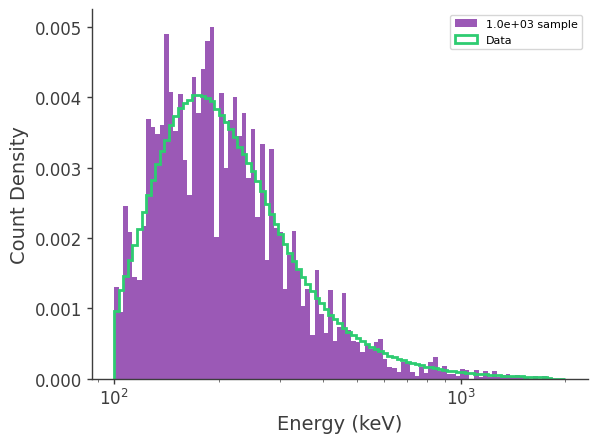

In [6]:
num_samples = 1000
bins = np.logspace(2, 3.3, 100)*u.keV
energy_samples = np.random.choice(data['Energies'], num_samples, replace=False) * u.keV

plt.hist(energy_samples, bins=bins, density=True, label=f'{num_samples:.1e} sample')
plt.hist(data['Energies'], bins=bins.value, density=True, lw=2, histtype='step', label='Data')
plt.xlabel('Energy (keV)')
plt.ylabel('Count Density')
plt.legend()
plt.xscale('log')

In [7]:
exposure_time = 100*92.3 * u.d * (len(energy_samples) / len(data['Energies'])) * 5/6 * 1/4      # Fudge factor, 3 month total, SAA cut, 25% FOV

hist = dr.project('Ei', 'Eps').slice[19:, :]
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
Aeff = dr2.get_effective_area

In [15]:
spectrum.K.free = True
spectrum.alpha.free = False
spectrum.xp.free = False
spectrum.beta.free = False
spectrum.piv.free = False

spectrum.K.max_value = K_inj * 10
spectrum.K.min_value = K_inj / 10

In [17]:
cosi = COSILikeNew('cosi',                                                     # COSI 3ML plugin
                 dr2 = dr2,                                                     # detector response
                 exposure_time = exposure_time,
                 energy_samples = energy_samples,
                 spectrum_unit = spectrum_unit,
                 nuisance_param = {}                                            # background parameter)       
)   

target_coord = SkyCoord.from_name('Crab').galactic
source = PointSource('source', 
                     l = target_coord.l.value,
                     b = target_coord.b.value,
                     spectral_shape = spectrum)
model = Model(source)
cosi.set_model(model)

In [18]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit()

07:54:09 INFO      set the minimizer to minuit                                             ]8;id=51979;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=342769;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

100%|██████████| 1000/1000 [00:15<00:00, 64.38it/s]


08:44:22 WARNING   49.480000000000004 percent of samples have been thrown away because     ]8;id=142394;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=455391;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  they failed the constraints on the parameters. This results might not be                         
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

08:44:22 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=622292;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=279527;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

Best fit values:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,9874.073966365313
total,9874.073966365313


Values of statistical measures:

,statistical measures
AIC,19750.15194074666
BIC,19755.05568800961


(                                value  negative_error  positive_error  \
 source.spectrum.main.Band.K  0.000076    8.250610e-14    6.043233e-13   
 
                                     error             unit  
 source.spectrum.main.Band.K  3.434147e-13  1 / (keV s cm2)  ,
         -log(likelihood)
 cosi   9874.073966365313
 total  9874.073966365313)

In [20]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(7.56000000 +/- 0.00000004) x 10^-5,1 / (keV s cm2)


Correlation matrix:

1.00


Values of -log(likelihood) at the minimum:

...

None


09:20:54 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=874687;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=624243;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=1386;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=117874;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=97134;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=350358;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

  * source (point source):
    * position:
      * l:
        * value: 184.55465500348814
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -5.783339352016455
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Band:
          * K:
            * value: 7.560000000000214e-05
            * desc: Differential flux at the pivot energy
            * min_value: 7.560000000000001e-05
            * max_value: 0.007560000000000001
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * alpha:
            * value: -1.99
            * desc: low-energy photon index
            * min_value: -2.14
            * max_value: 3.0
            * unit: ''
            * is_normalization: false
          * xp:
    

In [24]:
spectrum_inj = spectrum
spectrum_inj.K.value = K_inj

In [25]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
# binned_energy_edges = crab.binned_data.axes['Em'].edges.value
# binned_energy = np.array([])
# bin_sizes = np.array([])

# for i in range(len(binned_energy_edges)-1):
#     binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
#     bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

# expectation = cosi._expected_counts['source']

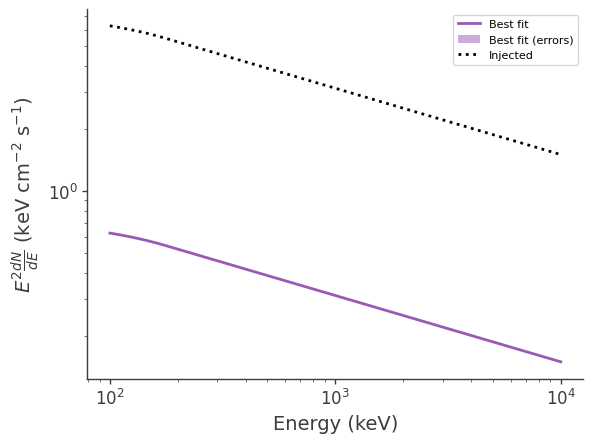

In [26]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

(<Axes: xlabel='Ei [keV]', ylabel='Eps'>,
 <matplotlib.collections.QuadMesh at 0x1775aadd0>)

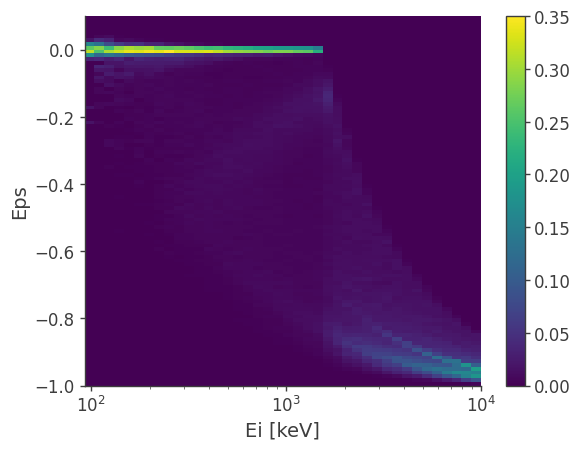

In [27]:
dr2.get_dispersion_matrix().plot()
# plt.xlim(right=2e3)

In [28]:
Em = 1650 * u.keV
rate_func = lambda E: spectrum(E.value) * spectrum_unit * dr2.get_interp_response({'Ei': E, 'Em': Em})
# Eaxis = dr2.project('Ei').rebin(1).axes['Ei']
Eaxis = dr2.axes['Ei']

idx = np.searchsorted(Eaxis.centers, Em, side='right')
offsetter = Em / Eaxis.centers[idx-1] #Em / Eaxis.centers[idx]
integral = sum(rate_func(Ei) * dE for Ei, dE in zip(Eaxis.centers * offsetter, Eaxis.widths * offsetter)) * exposure_time.to('s')       # Riemann sum approximation * exposure_time.to('s')       # Riemann sum approximation
integral

<Quantity 7.44886158e-05>

In [118]:
spectrum.K.value = K_inj.value
spectrum.xp.value = xp_inj #/ 5

In [113]:
Eaxis = dr2.axes['Ei']

aj = []
for Em in tqdm(energy_samples):
    rate_func = lambda E: spectrum(E.value) * spectrum_unit * dr2.get_interp_response({'Ei': E, 'Em': Em})
    idx = np.searchsorted(Eaxis.centers, Em, side='right')
    offsetter = Em / Eaxis.centers[idx-1] #Em / Eaxis.centers[idx]
    integral = sum(rate_func(Ei) * dE for Ei, dE in zip(Eaxis.centers * offsetter, Eaxis.widths * offsetter)) * exposure_time.to('s')       # Riemann sum approximation * exposure_time.to('s')       # Riemann sum approximation
    aj.append(integral)

aj = Quantity(aj)

# If spectrum is not normalized or if dr2.get_interp_response(...) isn't properly normalized over Em, 
# then the integral won't yield a valid probability density, and your log-likelihood will be off in scale. 
# You might want to precompute a full normalization constant:

np.sum(np.log(aj + 1e-12))

100%|██████████| 1000/1000 [00:14<00:00, 68.63it/s]


<Quantity 6829.07018832>

In [119]:
Eaxis = dr2.axes['Ei']
Epsedges = dr2.axes['Eps'].edges        # Can't densify further as get_interp_response only outputs (99,) shaped array
Epscenters = (Epsedges[:-1] + Epsedges[1:]) / 2

Eiedges = Eaxis.edges # densify_array(Eaxis.edges, k=1) * u.keV

integral = 0
for Ei_low, Ei_high in zip(Eiedges[:-1], Eiedges[1:]):
    Ei = (Ei_low + Ei_high) / 2
    rate_func = spectrum(Ei.value) * spectrum_unit * (Ei_high - Ei_low) * exposure_time.to('s')

    Em = dr2.transform_Eps_to_Em(Epscenters, Ei)
    Em_high = dr2.transform_Eps_to_Em(Epsedges[1:], Ei)
    Em_low = dr2.transform_Eps_to_Em(Epsedges[:-1], Ei)

    integral += rate_func * np.sum(dr2.get_interp_response({'Ei': Ei}) * (Em_high - Em_low)) / Ei      # The denominator is the Jacobian term discussed in 20240924-ResponseRelativeCoordinates-cosipy-Israel.pdf page 7 when integrating over dEm instead of dEps (R is in Eps coordinates). dEps / dEm = 1/Ei
    
c = integral
c

<Quantity 985.7628128>

In [115]:
np.sum(np.log(aj + 1e-12)) - c

<Quantity 6247.94090839>

In [ ]:
np.sum(np.log(aj + 1e-12)) - c

<Quantity 6372.75752724>

In [47]:
Eiedges = Eaxis.edges # densify_array(Eaxis.edges, k=1) * u.keV
expected_counts = np.sum([
    spectrum(E.value) * spectrum_unit * dr2.get_effective_area(E) * dE * exposure_time.to('s')
    for E, dE in zip((Eiedges[:-1]+Eiedges[1:])/2, np.diff(Eiedges))
])
expected_counts

887.187128345674

In [117]:
aj/c

<Quantity [2.66678462e+00, 2.68258133e+00, 2.44435848e+00, 1.91834996e+00,
           2.51499155e+00, 9.52289356e-01, 9.27902113e-01, 2.68790738e+00,
           2.64545799e+00, 5.96450479e-01, 1.72509090e+00, 2.59721599e+00,
           2.54588516e+00, 2.63764156e+00, 4.12617261e-01, 1.32974612e+00,
           1.88277240e+00, 1.95058685e+00, 2.31073172e+00, 7.91869730e-01,
           1.51845529e+00, 2.49069320e+00, 1.90166875e+00, 1.78388528e+00,
           2.59925398e+00, 1.76454163e+00, 2.22206916e+00, 1.57795928e+00,
           2.21215833e+00, 2.32618359e+00, 2.35206683e+00, 1.96784612e+00,
           1.93293938e+00, 2.37850335e+00, 2.66672137e+00, 2.55290388e+00,
           1.42098832e+00, 2.65915158e+00, 2.49336072e+00, 1.72874468e+00,
           2.06274935e+00, 2.24802663e+00, 2.49721630e+00, 1.98601643e+00,
           2.56836700e-01, 9.33627842e-01, 2.38314923e+00, 2.48198961e+00,
           2.46974197e+00, 7.53449733e-01, 2.60598439e+00, 8.92664766e-01,
           2.72902022e+00

In [24]:
def densify_array(centers, k):
    centers = np.asarray(centers)
    new_points = [
        np.linspace(start, end, k, endpoint=False) 
        for start, end in zip(centers[:-1], centers[1:])
    ]
    # Add the last original point
    new_points.append([centers[-1]])
    return np.concatenate(new_points)

In [ ]:
# Example usage
centers = Eaxis.centers
dense_centers = densify_array(centers, k=4) * u.keV
dense_centers

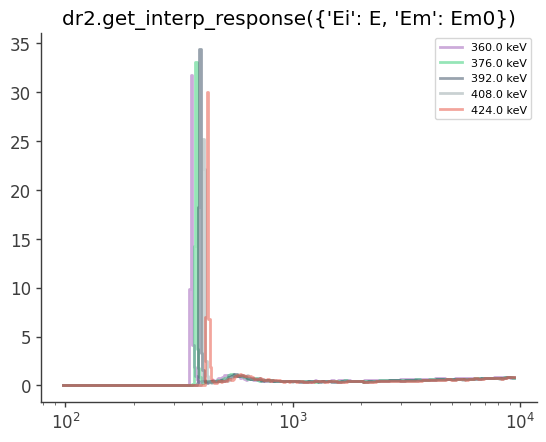

In [80]:
for Em0 in np.arange(360, 440, 16) * u.keV:
    centers = Eaxis.centers #+ Em0 - 399.66*u.keV
    # centers = centers[centers > 0]
    dense_centers = densify_array(centers, k=8) * u.keV
    plt.step(dense_centers, Quantity([dr2.get_interp_response({'Ei': E, 'Em': Em0}) for E in dense_centers]), label=f'{Em0}', alpha=0.5)
plt.xscale('log')
plt.title("dr2.get_interp_response({'Ei': E, 'Em': Em0})")
plt.legend()